# Gráficos executivos — geração a partir do Athena (`state_of_data_gold_v2`)

Lê as 9 queries de `../sql/queries_athena.sql` (mesmas 7 perguntas de
negócio, mesma regra já validada — nada é recriado aqui) e gera as imagens
usadas no material executivo, salvas em `output/`.

Escolha de forma por gráfico (ver seção de estilo mais abaixo para o porquê):

| # | Pergunta | Forma |
|---|---|---|
| 1 | Estrutura do mercado (cargos) | ranking (barra horizontal) |
| 2 | Respondentes por edição | barra simples |
| 3 | Perfis mais valorizados (senioridade × salário) | heatmap |
| 4 | Diversidade de gênero por ano | barra 100% empilhada |
| 5 | Tecnologias mais adotadas | ranking (barra horizontal) |
| 6 | Uso de IA, detalhado por ano | barra 100% empilhada |
| 7 | Adoção de IA, visão geral | barra 100% empilhada |
| 8 | Distribuição regional por ano | barra 100% empilhada |
| 9 | Senioridade por região | heatmap |

Rode as células em ordem, de cima pra baixo.

## 1. Credenciais do AWS Academy Lab

Cole as credenciais temporárias do **AWS Details** do seu Lab. Elas expiram
a cada sessão — se der erro de autenticação/token expirado, volte aqui,
cole as credenciais atualizadas e rode as células de novo.

In [ ]:
AWS_CREDENTIALS = {
    "aws_access_key_id": "",       # AWSAccessKeyId
    "aws_secret_access_key": "/pKUg1tsOcK6h",   # AWSSecretKey
    "aws_session_token": "",       # AWSSessionToken (obrigatório em credenciais temporárias do Lab)
    "region_name": "us-east-1",    # região do Lab -- confira no AWS Details
}

# Se o workgroup "primary" do Athena não tiver um "query result location"
# configurado, defina aqui um bucket/pasta pra salvar os resultados das
# queries. Se já rodou queries manualmente no console do Athena antes, pode
# deixar None.
ATHENA_S3_OUTPUT = None  # ex.: "s3://<algum-bucket>/athena-results/"

DATABASE = "state_of_data_gold_v2"

In [38]:
import boto3
import awswrangler as wr
import pandas as pd

boto3_session = boto3.Session(
    aws_access_key_id=AWS_CREDENTIALS["aws_access_key_id"] or None,
    aws_secret_access_key=AWS_CREDENTIALS["aws_secret_access_key"] or None,
    aws_session_token=AWS_CREDENTIALS["aws_session_token"] or None,
    region_name=AWS_CREDENTIALS["region_name"],
)

sts = boto3_session.client("sts")
print("Conectado como:", sts.get_caller_identity().get("Arn"))

Conectado como: arn:aws:sts::220856710497:assumed-role/voclabs/user5264977=pedropcs608@gmail.com


## 2. Ler as 9 queries de `sql/queries_athena.sql`

Nada de regra de negócio é reescrita aqui — o arquivo `.sql` já tem a lógica
validada (inclusive os cálculos de percentual por ano, feitos em SQL). Esta
célula só lê o arquivo, tira os comentários e separa os 9 `SELECT`s, na
ordem em que aparecem.

In [39]:
import re
from pathlib import Path

SQL_PATH = Path("../sql/queries_athena.sql")

# ordem das 9 queries tal como aparecem no arquivo -- ver seção 2 da conversa
# com o mentor para a conferência linha a linha dessa ordem.
CHAVES = [
    "q1_top_cargos",
    "q1_respondentes_por_ano",
    "q2_senioridade_salario",
    "q3_genero_por_ano",
    "q4_linguagens_2025",
    "q5_ia_detalhado",
    "q5_taxa_adocao",
    "q6_regiao",
    "q6_senioridade_regiao",
]


def parse_queries_sql(caminho: Path):
    """Le o .sql, remove os comentarios de linha (--) e devolve a lista de
    SELECTs na ordem em que aparecem -- sem duplicar nenhuma regra de
    negocio, so reaproveitando o que ja esta escrito e validado."""
    texto = caminho.read_text(encoding="utf-8")
    sem_comentarios = re.sub(r"--[^\n]*", "", texto)
    statements = [s.strip() for s in sem_comentarios.split(";")]
    return [s for s in statements if s]


queries = parse_queries_sql(SQL_PATH)
assert len(queries) == len(CHAVES), (
    f"Esperava {len(CHAVES)} queries em {SQL_PATH}, encontrei {len(queries)}. "
    "O arquivo .sql pode ter mudado -- confira antes de continuar."
)

QUERIES_POR_CHAVE = dict(zip(CHAVES, queries))

for chave, sql in QUERIES_POR_CHAVE.items():
    print(f"--- {chave} ---")
    print(sql[:90].replace("\n", " "), "...")

--- q1_top_cargos ---
SELECT cargo, "count" AS qtd_profissionais FROM state_of_data_gold_v2.q1_top_cargos ORDER  ...
--- q1_respondentes_por_ano ---
SELECT ano_pesquisa, "count" AS respondentes FROM state_of_data_gold_v2.q1_respondentes_po ...
--- q2_senioridade_salario ---
SELECT ano_pesquisa, senioridade, faixa_salarial, "count" AS qtd FROM state_of_data_gold_v ...
--- q3_genero_por_ano ---
SELECT     ano_pesquisa,     genero_padrao,     "count" AS qtd,     ROUND(100.0 * "count"  ...
--- q4_linguagens_2025 ---
SELECT ano_pesquisa, linguagem, "count" AS qtd FROM state_of_data_gold_v2.q4_linguagens_po ...
--- q5_ia_detalhado ---
SELECT     ano_pesquisa,     usa_ia_padrao,     "count" AS qtd,     ROUND(100.0 * "count"  ...
--- q5_taxa_adocao ---
SELECT     ano_pesquisa,     CASE WHEN usa_ia_padrao = 'Não usa IA' THEN 'Não usa' ELSE 'U ...
--- q6_regiao ---
SELECT ano_pesquisa, regiao, "count" AS qtd FROM state_of_data_gold_v2.q6_regiao ORDER BY  ...
--- q6_senioridade_regiao ---
SELECT 

## 3. Buscar os dados no Athena

Roda cada uma das 9 queries contra `state_of_data_gold_v2`. Se uma query
falhar, o erro fica registrado e as outras continuam.

In [40]:
def busca(sql: str):
    try:
        return wr.athena.read_sql_query(
            sql=sql,
            database=DATABASE,
            boto3_session=boto3_session,
            s3_output=ATHENA_S3_OUTPUT,
        )
    except Exception as e:
        print(f"[ERRO] ao rodar query: {e}")
        return None


resultados = {}
for chave, sql in QUERIES_POR_CHAVE.items():
    print(f"Buscando {chave} ...")
    resultados[chave] = busca(sql)

print("\nConcluido.")

Buscando q1_top_cargos ...


c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\awswrangler\athena\_utils.py:839: UserWarning: No `s3_output` was provided and the workgroup has no ResultConfiguration set. Falling back to the default bucket `aws-athena-query-results-{account}-{region}`. Because S3 bucket names are global, relying on this predictable default is discouraged: pass an explicit `s3_output`, or configure a workgroup with EnforceWorkGroupConfiguration=true and a ResultConfiguration.
  s3_output = _get_s3_output(s3_output=s3_output, wg_config=wg_config, boto3_session=boto3_session)


Buscando q1_respondentes_por_ano ...


c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\awswrangler\athena\_utils.py:839: UserWarning: No `s3_output` was provided and the workgroup has no ResultConfiguration set. Falling back to the default bucket `aws-athena-query-results-{account}-{region}`. Because S3 bucket names are global, relying on this predictable default is discouraged: pass an explicit `s3_output`, or configure a workgroup with EnforceWorkGroupConfiguration=true and a ResultConfiguration.
  s3_output = _get_s3_output(s3_output=s3_output, wg_config=wg_config, boto3_session=boto3_session)


Buscando q2_senioridade_salario ...


...

Buscando q6_regiao ...


c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\awswrangler\athena\_utils.py:839: UserWarning: No `s3_output` was provided and the workgroup has no ResultConfiguration set. Falling back to the default bucket `aws-athena-query-results-{account}-{region}`. Because S3 bucket names are global, relying on this predictable default is discouraged: pass an explicit `s3_output`, or configure a workgroup with EnforceWorkGroupConfiguration=true and a ResultConfiguration.
  s3_output = _get_s3_output(s3_output=s3_output, wg_config=wg_config, boto3_session=boto3_session)


Buscando q6_senioridade_regiao ...


c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\awswrangler\athena\_utils.py:839: UserWarning: No `s3_output` was provided and the workgroup has no ResultConfiguration set. Falling back to the default bucket `aws-athena-query-results-{account}-{region}`. Because S3 bucket names are global, relying on this predictable default is discouraged: pass an explicit `s3_output`, or configure a workgroup with EnforceWorkGroupConfiguration=true and a ResultConfiguration.
  s3_output = _get_s3_output(s3_output=s3_output, wg_config=wg_config, boto3_session=boto3_session)



Concluido.


### 3.1 Exportar dados brutos (conferência)


In [41]:
# Exporta os dados brutos de cada query para CSV (para conferencia exata
# dos numeros usados no material executivo, sem depender dos rotulos
# arredondados dos graficos).
import os
os.makedirs('output/dados', exist_ok=True)
for _chave, _df in resultados.items():
    if _df is not None:
        _df.to_csv(f'output/dados/{_chave}.csv', index=False)
print('Dados exportados para output/dados/')


Dados exportados para output/dados/


## 4. Estilo visual

In [42]:
import textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# paleta categorica 
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
CATEGORICAL_ORDER = ["blue", "orange", "aqua", "yellow", "magenta", "green", "violet", "red"]

# rampa sequencial (um so hue, claro -> escuro) para os heatmaps
SEQUENTIAL_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.size": 11,
})


def _luminancia(hex_cor):
    hex_cor = hex_cor.lstrip("#")
    r, g, b = (int(hex_cor[i:i + 2], 16) / 255 for i in (0, 2, 4))
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def _texto_para_fundo(hex_cor):
    return "#ffffff" if _luminancia(hex_cor) < 0.55 else INK_PRIMARY


def _wrap_label(texto, largura=28):
    return "\n".join(textwrap.wrap(str(texto), largura)) or str(texto)


def _titulo(fig, ax, titulo, subtitulo=None):
    ax.set_title(titulo, loc="left", color=INK_PRIMARY, fontsize=14, fontweight="bold",
                 pad=26 if subtitulo else 12)
    if subtitulo:
        ax.text(0, 1.035, subtitulo, transform=ax.transAxes, ha="left", va="bottom",
                 fontsize=10.5, color=INK_SECONDARY)


def _salvar(fig, fname):
    fig.tight_layout()
    if fname:
        caminho = OUTPUT_DIR / fname
        fig.savefig(caminho, dpi=200, facecolor=SURFACE, bbox_inches="tight")
        print("Salvo:", caminho)
    plt.show()


def _pronta(chave):
    df = resultados.get(chave)
    if df is None:
        print(f"[pulado] sem dados para {chave} (ver erro na secao 3)")
        return None
    return df.copy()

In [43]:
def ranked_hbar(categorias, valores, titulo, subtitulo=None, fname=None, cor=None):
    """Ranking: barra horizontal, ordenada, uma serie so -> sem legenda,
    rotulo direto na ponta de cada barra."""
    cor = cor or PALETTE["blue"]
    categorias = list(categorias)
    valores = [float(v) for v in valores]
    ordem = sorted(range(len(valores)), key=lambda i: valores[i])
    categorias = [categorias[i] for i in ordem]
    valores = [valores[i] for i in ordem]

    altura = max(3.2, 0.55 * len(categorias) + 1.2)
    fig, ax = plt.subplots(figsize=(9, altura))

    y_pos = range(len(categorias))
    ax.barh(y_pos, valores, height=0.6, color=cor, zorder=3)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([_wrap_label(c) for c in categorias], color=INK_SECONDARY)

    max_valor = max(valores) if valores else 0
    for i, v in enumerate(valores):
        ax.text(v + max_valor * 0.015, i, f"{v:,.0f}".replace(",", "."),
                 va="center", ha="left", color=INK_PRIMARY, fontsize=10)

    ax.set_xlim(0, max_valor * 1.15 if max_valor else 1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", colors=INK_MUTED)
    ax.xaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)

    _titulo(fig, ax, titulo, subtitulo)
    _salvar(fig, fname)
    return fig


def simple_bar(categorias, valores, titulo, subtitulo=None, fname=None, cor=None):
    """Barra simples vertical -- poucas categorias (ex.: anos), uma serie so."""
    cor = cor or PALETTE["blue"]
    categorias = [str(c) for c in categorias]
    valores = [float(v) for v in valores]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = range(len(categorias))
    barras = ax.bar(x, valores, width=0.5, color=cor, zorder=3)

    ax.set_xticks(list(x))
    ax.set_xticklabels(categorias, color=INK_SECONDARY)

    max_valor = max(valores) if valores else 0
    for rect, v in zip(barras, valores):
        ax.text(rect.get_x() + rect.get_width() / 2, v + max_valor * 0.02,
                 f"{v:,.0f}".replace(",", "."), ha="center", va="bottom",
                 color=INK_PRIMARY, fontsize=10)

    ax.set_ylim(0, max_valor * 1.2 if max_valor else 1)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(axis="x", length=0)

    _titulo(fig, ax, titulo, subtitulo)
    _salvar(fig, fname)
    return fig

In [44]:
def stacked_pct_bar(anos, tabela_pct, ordem_categorias, titulo, subtitulo=None,
                     fname=None, cor_por_categoria=None):
    """Barra 100% empilhada -- composicao ao longo das 3 edicoes. Gap de 2px
    (cor da superficie) entre segmentos; legenda sempre presente (>=2 series);
    rotulo direto so em segmentos com espaco (>=5%)."""
    if cor_por_categoria is None:
        cor_por_categoria = {
            cat: PALETTE[CATEGORICAL_ORDER[i]] for i, cat in enumerate(ordem_categorias)
        }

    fig, ax = plt.subplots(figsize=(7.5, 5))
    x = range(len(anos))
    base = [0.0] * len(anos)

    for cat in ordem_categorias:
        valores = tabela_pct.get(cat, [0.0] * len(anos))
        barras = ax.bar(x, valores, bottom=base, width=0.55,
                         color=cor_por_categoria[cat], edgecolor=SURFACE, linewidth=1.5,
                         label=cat, zorder=3)
        for rect, v, b in zip(barras, valores, base):
            if v >= 5:
                cor_texto = _texto_para_fundo(cor_por_categoria[cat])
                ax.text(rect.get_x() + rect.get_width() / 2, b + v / 2, f"{v:.0f}%",
                         ha="center", va="center", color=cor_texto, fontsize=9.5)
        base = [b + v for b, v in zip(base, valores)]

    ax.set_xticks(list(x))
    ax.set_xticklabels([str(a) for a in anos], color=INK_SECONDARY)
    ax.set_ylim(0, 100)
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="x", length=0)

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08),
               ncol=min(len(ordem_categorias), 3), frameon=False, fontsize=9.5,
               labelcolor=INK_SECONDARY)

    _titulo(fig, ax, titulo, subtitulo)
    _salvar(fig, fname)
    return fig


def heatmap(linhas, colunas, matriz, titulo, subtitulo=None, fname=None, fmt="{:.0f}"):
    """Heatmap sequencial (um hue so) -- comparacao de duas dimensoes categoricas."""
    matriz_np = np.array(matriz, dtype=float)
    cmap = LinearSegmentedColormap.from_list("sequencial_azul", SEQUENTIAL_BLUE)

    fig, ax = plt.subplots(figsize=(1.15 * len(colunas) + 3, 0.7 * len(linhas) + 2))
    ax.imshow(matriz_np, cmap=cmap, aspect="auto")

    ax.set_xticks(range(len(colunas)))
    ax.set_xticklabels([_wrap_label(c, 18) for c in colunas], rotation=30, ha="right",
                         color=INK_SECONDARY)
    ax.set_yticks(range(len(linhas)))
    ax.set_yticklabels(linhas, color=INK_SECONDARY)
    ax.tick_params(length=0)

    if len(colunas) > 1:
        ax.set_xticks([x - 0.5 for x in range(1, len(colunas))], minor=True)
    if len(linhas) > 1:
        ax.set_yticks([y - 0.5 for y in range(1, len(linhas))], minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=3)
    ax.tick_params(which="minor", length=0)

    vmax = matriz_np.max() if matriz_np.size else 1
    for i in range(matriz_np.shape[0]):
        for j in range(matriz_np.shape[1]):
            valor = matriz_np[i, j]
            cor_celula = cmap(valor / vmax if vmax else 0)
            cor_texto = _texto_para_fundo(mcolors.to_hex(cor_celula))
            ax.text(j, i, fmt.format(valor), ha="center", va="center",
                     color=cor_texto, fontsize=9.5)

    for spine in ax.spines.values():
        spine.set_visible(False)

    _titulo(fig, ax, titulo, subtitulo)
    _salvar(fig, fname)
    return fig

## 5. Ordens e cores por categoria

Definidas uma única vez aqui e reaproveitadas em todos os gráficos que
usam essas dimensões — consistência visual entre os 9 gráficos.

In [45]:
SENIORIDADE_ORDEM = ["Júnior", "Pleno", "Sênior", "Nível Gerencial", "Nível Direção"]

FAIXA_ORDEM = [
    "Menos de R$ 1.000/mês", "de R$ 1.001/mês a R$ 2.000/mês",
    "de R$ 2.001/mês a R$ 3000/mês", "de R$ 3.001/mês a R$ 4.000/mês",
    "de R$ 4.001/mês a R$ 6.000/mês", "de R$ 6.001/mês a R$ 8.000/mês",
    "de R$ 8.001/mês a R$ 12.000/mês", "de R$ 12.001/mês a R$ 16.000/mês",
    "de R$ 16.001/mês a R$ 20.000/mês", "de R$ 20.001/mês a R$ 25.000/mês",
    "Acima de R$ 25.000/mês", "Acima de 25.001/mês",
]

GENERO_ORDEM = ["Masculino", "Feminino", "Prefiro não informar", "Outros"]

IA_ORDEM = ["Não usa IA", "Usa - versão gratuita", "Usa - copilot/código",
            "Usa - paga do bolso", "Usa - empresa paga"]
IA_CORES = {
    "Não usa IA": INK_MUTED,
    "Usa - versão gratuita": PALETTE["blue"],
    "Usa - copilot/código": PALETTE["orange"],
    "Usa - paga do bolso": PALETTE["aqua"],
    "Usa - empresa paga": PALETTE["yellow"],
}

GRUPO_ADOCAO_ORDEM = ["Usa algum tipo de IA", "Não usa"]
GRUPO_ADOCAO_CORES = {"Usa algum tipo de IA": PALETTE["blue"], "Não usa": INK_MUTED}

REGIAO_ORDEM = ["Sudeste", "Sul", "Nordeste", "Centro-oeste", "Norte"]

## Gráfico 1 — Estrutura do mercado (cargos)

Salvo: output\01_top_cargos.png


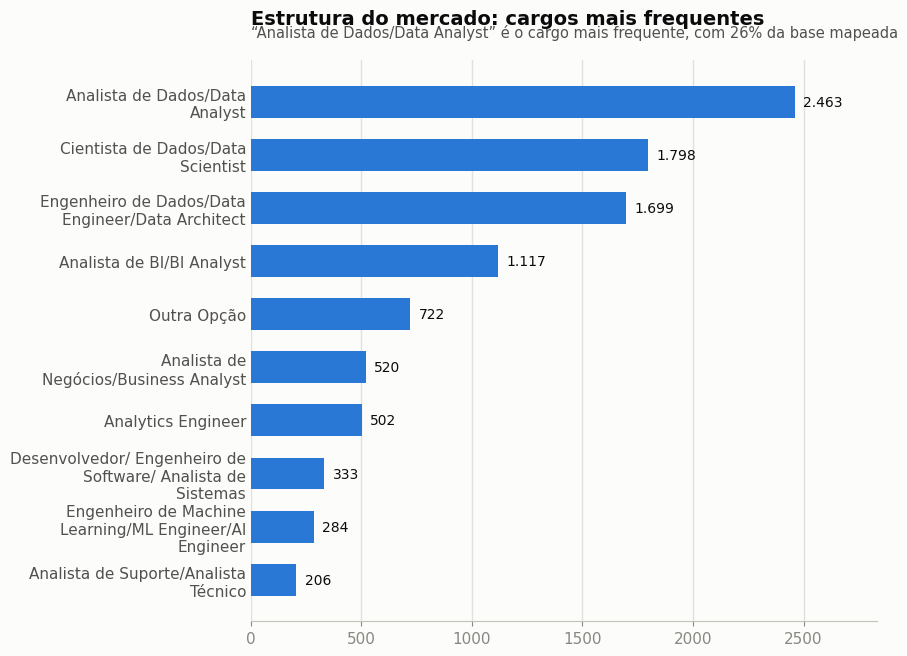

In [46]:
df = _pronta("q1_top_cargos")
if df is not None:
    df = df.sort_values("qtd_profissionais", ascending=False).reset_index(drop=True)
    top_cargo = df.iloc[0]["cargo"]
    pct_top = 100 * df.iloc[0]["qtd_profissionais"] / df["qtd_profissionais"].sum()

    ranked_hbar(
        categorias=df["cargo"],
        valores=df["qtd_profissionais"],
        titulo="Estrutura do mercado: cargos mais frequentes",
        subtitulo=f"“{top_cargo}” é o cargo mais frequente, com {pct_top:.0f}% da base mapeada",
        fname="01_top_cargos.png",
    )

## Gráfico 2 — Respondentes por edição

Salvo: output\02_respondentes_por_ano.png


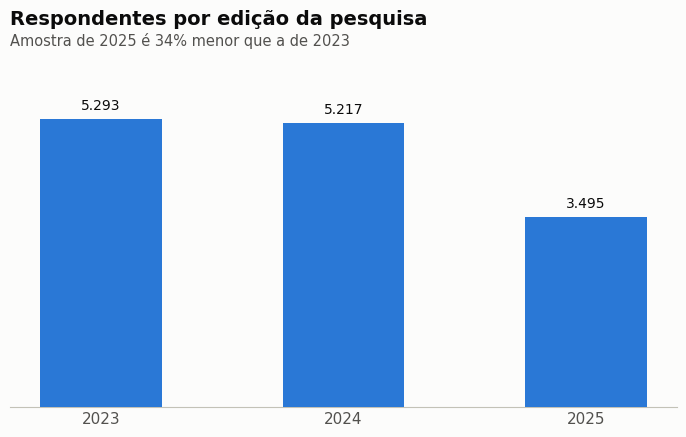

In [47]:
df = _pronta("q1_respondentes_por_ano")
if df is not None:
    df = df.sort_values("ano_pesquisa").reset_index(drop=True)
    primeiro, ultimo = df.iloc[0], df.iloc[-1]
    variacao_pct = 100 * (ultimo["respondentes"] - primeiro["respondentes"]) / primeiro["respondentes"]
    direcao = "menor" if variacao_pct < 0 else "maior"

    simple_bar(
        categorias=df["ano_pesquisa"],
        valores=df["respondentes"],
        titulo="Respondentes por edição da pesquisa",
        subtitulo=f"Amostra de {ultimo['ano_pesquisa']} é {abs(variacao_pct):.0f}% {direcao} que a de {primeiro['ano_pesquisa']}",
        fname="02_respondentes_por_ano.png",
    )

## Gráfico 3 — Perfis mais valorizados (senioridade × faixa salarial, 2025)

Salvo: output\03_senioridade_salario_2025.png


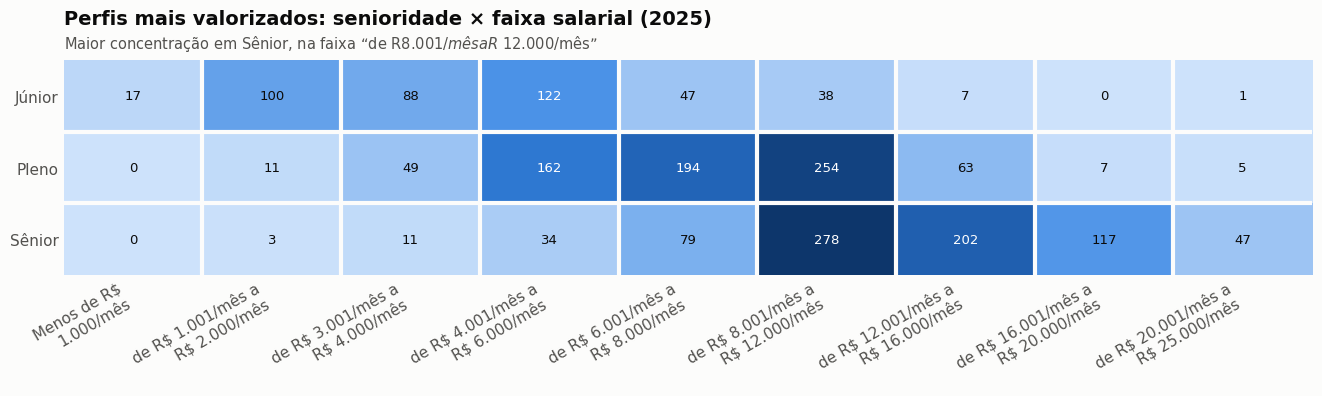

In [48]:
df = _pronta("q2_senioridade_salario")
if df is not None:
    senioridades = [s for s in SENIORIDADE_ORDEM if s in df["senioridade"].unique()]
    faixas = [f for f in FAIXA_ORDEM if f in df["faixa_salarial"].unique()]

    pivot = (
        df.pivot_table(index="senioridade", columns="faixa_salarial", values="qtd",
                        aggfunc="sum", fill_value=0)
        .reindex(index=senioridades, columns=faixas, fill_value=0)
    )

    max_i, max_j = np.unravel_index(pivot.values.argmax(), pivot.values.shape)

    heatmap(
        linhas=list(pivot.index),
        colunas=list(pivot.columns),
        matriz=pivot.values,
        titulo="Perfis mais valorizados: senioridade × faixa salarial (2025)",
        subtitulo=f"Maior concentração em {pivot.index[max_i]}, na faixa “{pivot.columns[max_j]}”",
        fname="03_senioridade_salario_2025.png",
    )

## Gráfico 4 — Diversidade de gênero por ano

Salvo: output\04_genero_por_ano.png


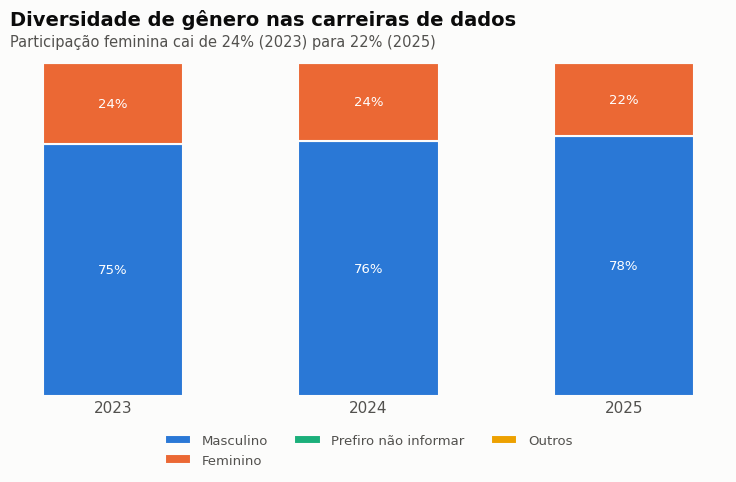

In [49]:
df = _pronta("q3_genero_por_ano")
if df is not None:
    anos = sorted(df["ano_pesquisa"].unique())
    tabela_pct = {
        cat: [float(df[(df["ano_pesquisa"] == a) & (df["genero_padrao"] == cat)]["pct_no_ano"].sum())
              for a in anos]
        for cat in GENERO_ORDEM
    }
    fem_inicio, fem_fim = tabela_pct["Feminino"][0], tabela_pct["Feminino"][-1]
    tendencia = "cai" if fem_fim < fem_inicio else "sobe"

    stacked_pct_bar(
        anos=anos,
        tabela_pct=tabela_pct,
        ordem_categorias=GENERO_ORDEM,
        titulo="Diversidade de gênero nas carreiras de dados",
        subtitulo=f"Participação feminina {tendencia} de {fem_inicio:.0f}% ({anos[0]}) para {fem_fim:.0f}% ({anos[-1]})",
        fname="04_genero_por_ano.png",
    )

## Gráfico 5 — Tecnologias mais adotadas (2025)

Salvo: output\05_linguagens_2025.png


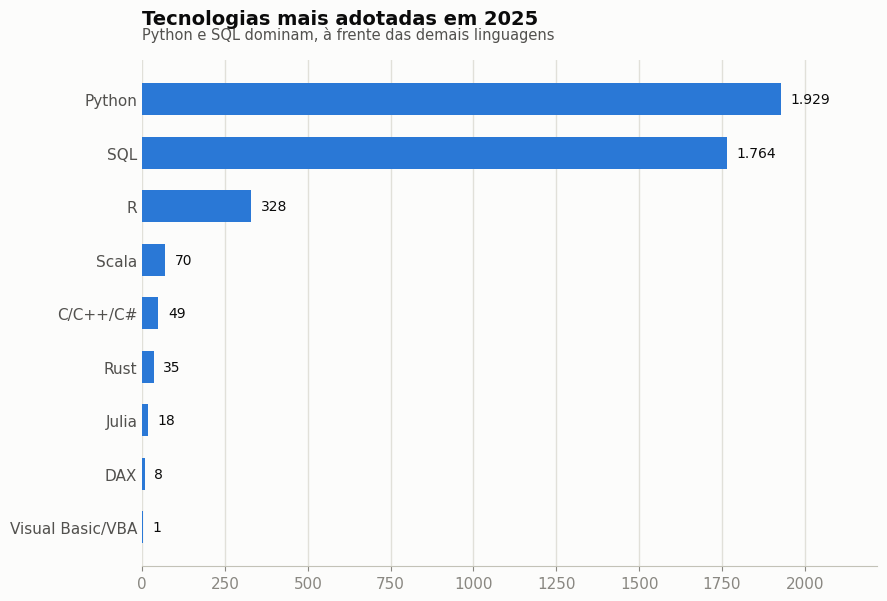

In [50]:
df = _pronta("q4_linguagens_2025")
if df is not None:
    df = df.sort_values("qtd", ascending=False).reset_index(drop=True)
    top1, top2 = df.iloc[0], df.iloc[1]

    ranked_hbar(
        categorias=df["linguagem"],
        valores=df["qtd"],
        titulo="Tecnologias mais adotadas em 2025",
        subtitulo=f"{top1['linguagem']} e {top2['linguagem']} dominam, à frente das demais linguagens",
        fname="05_linguagens_2025.png",
    )

## Gráfico 6 — Uso de IA, detalhado por ano

Salvo: output\06_ia_detalhado_por_ano.png


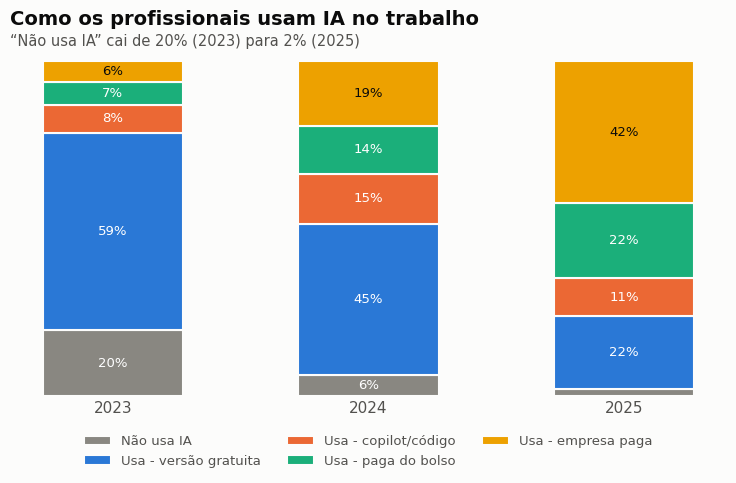

In [51]:
df = _pronta("q5_ia_detalhado")
if df is not None:
    anos = sorted(df["ano_pesquisa"].unique())
    tabela_pct = {
        cat: [float(df[(df["ano_pesquisa"] == a) & (df["usa_ia_padrao"] == cat)]["pct_no_ano"].sum())
              for a in anos]
        for cat in IA_ORDEM
    }
    nao_usa_inicio, nao_usa_fim = tabela_pct["Não usa IA"][0], tabela_pct["Não usa IA"][-1]

    stacked_pct_bar(
        anos=anos,
        tabela_pct=tabela_pct,
        ordem_categorias=IA_ORDEM,
        cor_por_categoria=IA_CORES,
        titulo="Como os profissionais usam IA no trabalho",
        subtitulo=f"“Não usa IA” cai de {nao_usa_inicio:.0f}% ({anos[0]}) para {nao_usa_fim:.0f}% ({anos[-1]})",
        fname="06_ia_detalhado_por_ano.png",
    )

## Gráfico 7 — Adoção de IA, visão geral

Salvo: output\07_taxa_adocao_ia.png


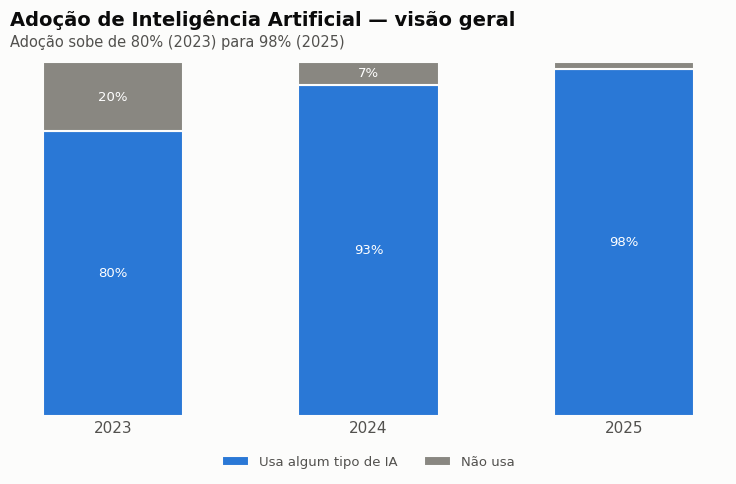

In [52]:
df = _pronta("q5_taxa_adocao")
if df is not None:
    anos = sorted(df["ano_pesquisa"].unique())
    totais = df.groupby("ano_pesquisa")["qtd"].sum()

    tabela_pct = {
        cat: [100 * float(df[(df["ano_pesquisa"] == a) & (df["grupo"] == cat)]["qtd"].sum()) / totais[a]
              for a in anos]
        for cat in GRUPO_ADOCAO_ORDEM
    }
    usa_inicio = tabela_pct["Usa algum tipo de IA"][0]
    usa_fim = tabela_pct["Usa algum tipo de IA"][-1]

    stacked_pct_bar(
        anos=anos,
        tabela_pct=tabela_pct,
        ordem_categorias=GRUPO_ADOCAO_ORDEM,
        cor_por_categoria=GRUPO_ADOCAO_CORES,
        titulo="Adoção de Inteligência Artificial — visão geral",
        subtitulo=f"Adoção sobe de {usa_inicio:.0f}% ({anos[0]}) para {usa_fim:.0f}% ({anos[-1]})",
        fname="07_taxa_adocao_ia.png",
    )

## Gráfico 8 — Distribuição geográfica por ano

Salvo: output\08_regiao_por_ano.png


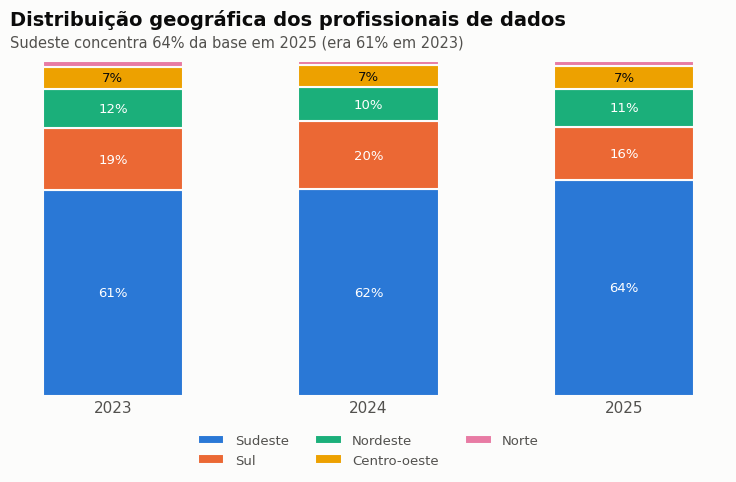

In [53]:
df = _pronta("q6_regiao")
if df is not None:
    anos = sorted(df["ano_pesquisa"].unique())
    totais = df.groupby("ano_pesquisa")["qtd"].sum()
    regioes_presentes = [r for r in REGIAO_ORDEM if r in df["regiao"].unique()]

    tabela_pct = {
        reg: [100 * float(df[(df["ano_pesquisa"] == a) & (df["regiao"] == reg)]["qtd"].sum()) / totais[a]
              for a in anos]
        for reg in regioes_presentes
    }
    sudeste_inicio = tabela_pct.get("Sudeste", [0])[0]
    sudeste_fim = tabela_pct.get("Sudeste", [0])[-1]

    stacked_pct_bar(
        anos=anos,
        tabela_pct=tabela_pct,
        ordem_categorias=regioes_presentes,
        titulo="Distribuição geográfica dos profissionais de dados",
        subtitulo=f"Sudeste concentra {sudeste_fim:.0f}% da base em {anos[-1]} (era {sudeste_inicio:.0f}% em {anos[0]})",
        fname="08_regiao_por_ano.png",
    )

## Gráfico 9 — Senioridade por região (2025)

Salvo: output\09_senioridade_por_regiao_2025.png


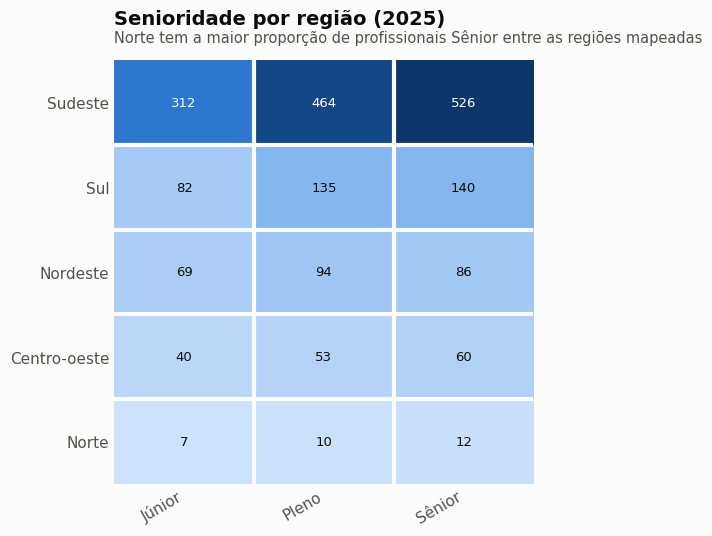

In [54]:
df = _pronta("q6_senioridade_regiao")
if df is not None:
    regioes_presentes = [r for r in REGIAO_ORDEM if r in df["regiao"].unique()]
    senioridades_presentes = [s for s in SENIORIDADE_ORDEM if s in df["senioridade"].unique()]

    pivot = (
        df.pivot_table(index="regiao", columns="senioridade", values="qtd",
                        aggfunc="sum", fill_value=0)
        .reindex(index=regioes_presentes, columns=senioridades_presentes, fill_value=0)
    )

    subtitulo = None
    if "Sênior" in pivot.columns and pivot.sum(axis=1).min() > 0:
        prop_senior = pivot["Sênior"] / pivot.sum(axis=1)
        regiao_top = prop_senior.idxmax()
        subtitulo = f"{regiao_top} tem a maior proporção de profissionais Sênior entre as regiões mapeadas"

    heatmap(
        linhas=list(pivot.index),
        colunas=list(pivot.columns),
        matriz=pivot.values,
        titulo="Senioridade por região (2025)",
        subtitulo=subtitulo,
        fname="09_senioridade_por_regiao_2025.png",
    )